In [2]:
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
from matplotlib.pyplot import figure
import pandas as pd
from scipy import integrate
import numpy.matlib
from scipy.optimize import curve_fit
from scipy.stats import norm
import statistics
from collections import deque
from operator import add
plt.style.use("seaborn-v0_8-white")
matplotlib.rcParams['axes.labelsize'] = 20
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['xtick.labelsize'] = 15
matplotlib.rcParams['xtick.major.size'] = 10
matplotlib.rcParams['xtick.minor.size'] = 5
matplotlib.rcParams['ytick.labelsize'] = 15
matplotlib.rcParams['ytick.major.size'] = 10
matplotlib.rcParams['ytick.minor.size'] = 5


In [3]:


def Two_dose(y, t, pars):
    dy = np.zeros(7)  # compartments: S, S1, S2, I, B1, B2, R
    S, S1, S2, I, B1, B2, R = y

    N = S + S1 + S2 + I + B1 + B2 + R
    I_tot = I + B1 + B2

    
    dy[0] = pars['b'] - (pars['beta'] * S / N) * I_tot - pars['v1'] * pars['p1'] * S - pars['m'] * S
    dy[1] = pars['v1'] * pars['p1'] * pars['eps1'] * S - (pars['beta'] * S1 / N) * I_tot - pars['v2'] * pars['p2'] * S1 - pars['m'] * S1
    dy[2] = pars['v2'] * pars['p2'] * pars['eps2'] * S1 - (pars['beta'] * S2 / N) * I_tot - pars['m'] * S2
    dy[3] = (pars['beta'] * S / N) * I_tot - pars['gamma'] * I - pars['m'] * I
    dy[4] = (pars['beta'] * S1 / N) * I_tot - pars['gamma'] * B1 - pars['m'] * B1
    dy[5] = (pars['beta'] * S2 / N) * I_tot - pars['gamma'] * B2 - pars['m'] * B2
    dy[6] = pars['v1'] * pars['p1'] * (1 - pars['eps1']) * S + pars['v2'] * pars['p2'] * (1 - pars['eps2']) * S1 + pars['gamma'] * I_tot - pars['m'] * R

    return dy


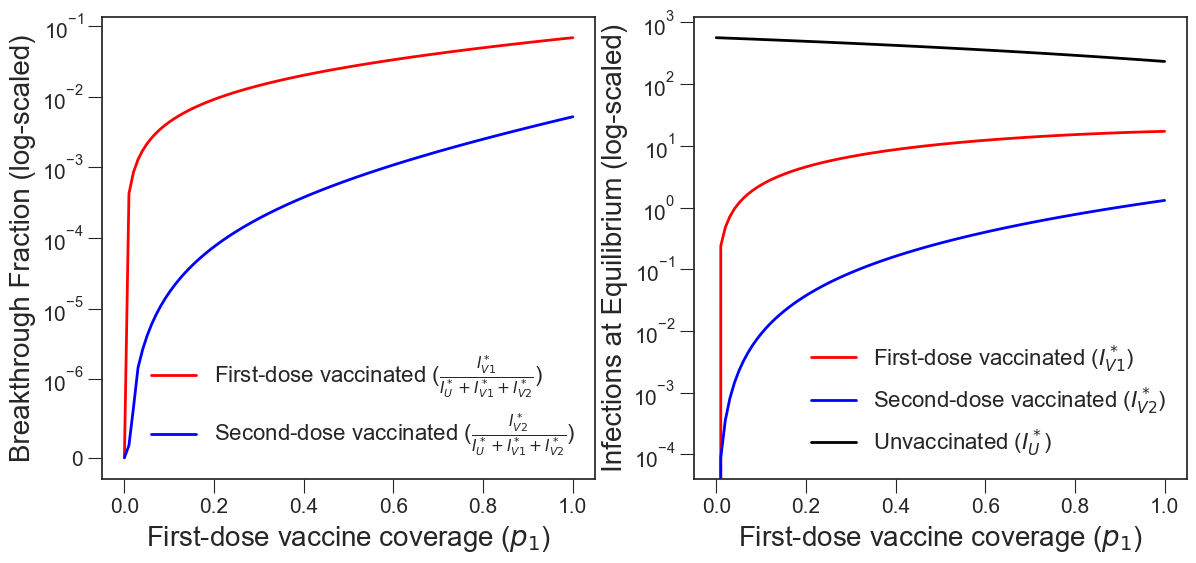

In [4]:
p1_vals = np.linspace(0,1,100)

fv1 = []
fv2 = []
fv3 = []

rv1 = []
rv2 = []
rv3 = []
for i in p1_vals:
    pars = {}
    pars['eps1'] = 0.07
    pars['eps2'] = 0.03/pars['eps1']
    pars['gamma'] = 1/10
    pars['beta'] = 1.515
    pars['p1'] = i
    pars['p2'] = i

    pars['v1'] = 1/(365/2)
    pars['v2'] = 1/(365*3.5)
    pars['m'] = 1/(365*4.5)
    pars['b'] = pars['m']
    
    t = np.arange(0,365*50)
    y0 = np.zeros(7)
    N = 10**5
    y0[0] = (N - 1)/N
    y0[3] = 1/N
    y = integrate.odeint(Two_dose, y0, t, atol=1e-8, args=(pars,))
    
    S, S1, S2, I, B1, B2, R  = y.T

    fv1.append(np.array(B1[-1])/(np.array(I[-1]) + np.array(B1[-1]) + np.array(B2[-1])))
    fv2.append(np.array(B2[-1])/(np.array(I[-1]) + np.array(B1[-1]) + np.array(B2[-1])))
    fv3.append(np.array(I[-1])/(np.array(I[-1]) + np.array(B1[-1]) + np.array(B2[-1])))
    

    rv1.append(np.array(B1[-1]))
    rv2.append(np.array(B2[-1]))
    rv3.append(np.array(I[-1]))
    
    
    #plt.plot(t,y)
    #plt.show()



fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# Left: breakthrough fractions (equilibrium proportions)
ax = axes[0]
ax.plot(p1_vals, fv1, linewidth=2, color='red',
        label=r'First-dose vaccinated ($\frac{I_{V1}^*}{I_U^* + I_{V1}^* + I_{V2}^*}$)')
ax.plot(p1_vals, fv2, linewidth=2, color='blue',
        
        label=r'Second-dose vaccinated ($\frac{I_{V2}^*}{I_U^* + I_{V1}^* + I_{V2}^*}$)')
ax.set_xlabel('First-dose vaccine coverage ($p_1$)', fontsize=20)
ax.set_ylabel('Breakthrough Fraction (log-scaled)', fontsize=20)
ax.legend(fontsize=16, loc='lower right')
ax.set_yscale('symlog', linthresh=1e-6)  # use symlog to handle zeros safely
ax.minorticks_off()
ax.tick_params(axis='y', which='minor', length=0)

# no grid for a cleaner figure

# Right: counts at equilibrium
# Right: counts at equilibrium
ax2 = axes[1]
ax2.plot(p1_vals, np.array(rv1) * (N), linewidth=2, color='red',
         label=r'First-dose vaccinated ($I_{V1}^*$)')
ax2.plot(p1_vals, np.array(rv2) * (N), linewidth=2, color='blue',
         label=r'Second-dose vaccinated ($I_{V2}^*$)')
ax2.plot(p1_vals, np.array(rv3) * (N), linewidth=2, color='black',
         label=r'Unvaccinated ($I_U^*$)')
ax2.set_xlabel('First-dose vaccine coverage ($p_1$)', fontsize=20)
ax2.set_ylabel('Infections at Equilibrium (log-scaled)', fontsize=20)
ax2.legend(fontsize=16, loc='lower right')
ax2.set_yscale('log')

# 🔥 Turn OFF minor ticks on second subplot
ax2.minorticks_off()
ax2.tick_params(axis='y', which='minor', length=0)
plt.savefig('TwoDose_Breakthroughs.pdf', bbox_inches='tight')
plt.show()


### Note used for paper but still cool: Taking second dose too quickly ($v_2 \times a$) but also higher conditional second dose failure rate  ($\epsilon_2\times b$)

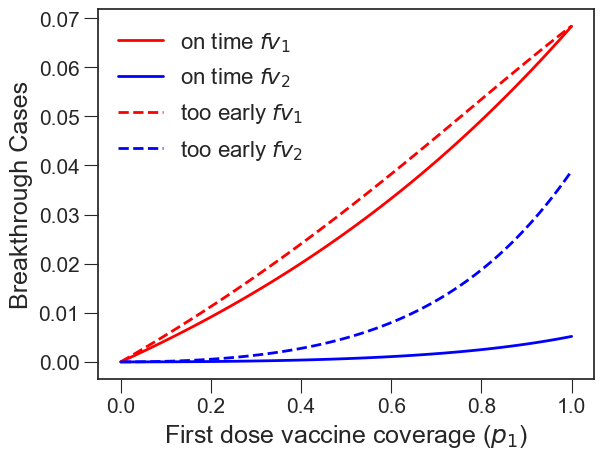

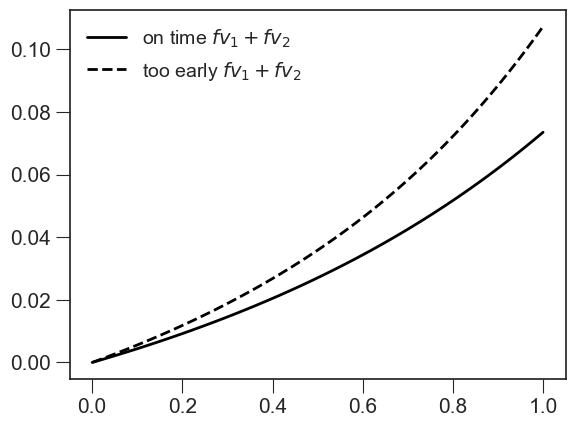

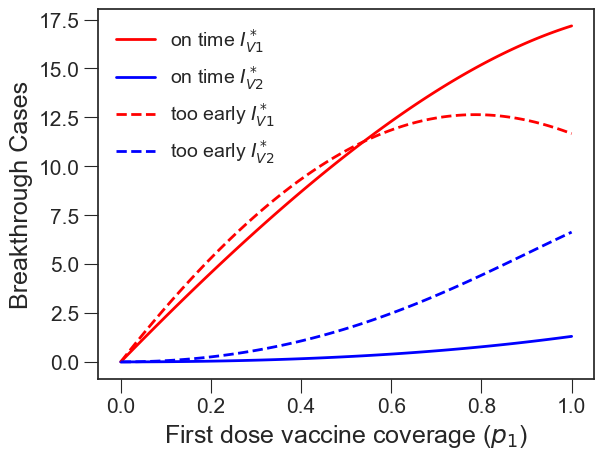

Text(0, 0.5, 'Breakthrough Cases')

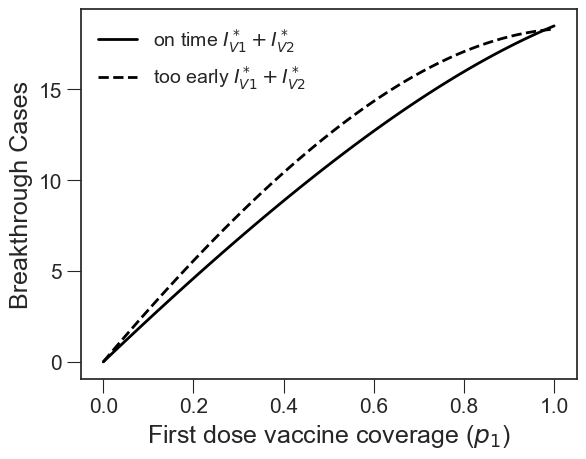

In [5]:
p1_vals = np.linspace(0,1,100)
fv1_early = []
fv2_early= []
rv1_early = []
rv2_early  = []
a = 3
b = 1.5
for i in p1_vals:
    pars = {}
    R0 = 12
    pars['eps1'] = 0.07
    pars['eps2'] = min(1,b* 0.03/pars['eps1'])
    pars['gamma'] = 1/10
    pars['beta'] = pars['gamma'] * R0
    pars['p1'] = i
    pars['p2'] = pars['p1']
    pars['v1'] = 1/(365/2)
    pars['v2'] = a*1/(365*3.5)
    pars['m'] = 1/(365*4.5)
    pars['b'] = pars['m']
    
    t = np.arange(0,365*10)
    y0 = np.zeros(7)
    N = 10**5
    y0[0] = (N - 1)/(N)
    y0[3] = 1/(N)
    y = integrate.odeint(Two_dose, y0, t, atol=1e-8, args=(pars,))
    
    S, S1, S2, I, B1, B2, R  = y.T
    
    fv1_early.append(np.array(B1[-1])/(np.array(I[-1]) + np.array(B1[-1]) + np.array(B2[-1])))
    fv2_early.append(np.array(B2[-1])/(np.array(I[-1]) + np.array(B1[-1]) + np.array(B2[-1])))
    rv1_early.append(np.array(B1[-1]))
    rv2_early.append(np.array(B2[-1]))
    #plt.plot(t,y)
    #plt.show()
#plt.figure(figsize=(5,4))
#plt.plot(p1_vals, fv1_early, linewidth=2, color='red', label = r'$\frac{I_{V1}}{I + I_{V1} + I_{V2}}$')
#plt.plot(p1_vals, fv2_early, linewidth=2, color='blue', label = r'$\frac{I_{V2}}{I + I_{V1} + I_{V2}}$')
#plt.xlabel(r'First dose vaccine coverage ($p_1$)', fontsize = 18)
#plt.ylabel('Breakthrough Fraction', fontsize = 18)
#plt.legend(fontsize = 14)
#plt.yscale('log')
plt.show()
plt.plot(p1_vals, fv1, color = 'red', linewidth=2, label = r'on time $fv_1$')
plt.plot(p1_vals, fv2,color = 'blue',  linewidth=2, label = r'on time $fv_2$')
plt.plot(p1_vals, fv1_early, linewidth=2, color='red', linestyle = '--',label = r'too early $fv_1$')
plt.plot(p1_vals, fv2_early, linewidth=2, color='blue',linestyle = '--', label = r'too early $fv_2$')

plt.xlabel(r'First dose vaccine coverage ($p_1$)', fontsize = 18)
plt.ylabel('Breakthrough Cases', fontsize = 18)
plt.legend(fontsize = 16 )
plt.show()
plt.plot(p1_vals,np.array(fv1)+np.array(fv2),color = 'black', linewidth=2, label = r'on time $fv_1+fv_2$')
plt.plot(p1_vals,np.array(fv1_early)+np.array(fv2_early), color = 'black', linewidth=2,linestyle = '--', label = r'too early $fv_1+fv_2$')
plt.legend(fontsize = 14)
plt.show()

plt.plot(p1_vals, np.array(rv1)*(N), linewidth=2, color='red', label = r'on time $I_{V1}^*$')
plt.plot(p1_vals, np.array(rv2)*(N), linewidth=2, color='blue', label = r'on time $I_{V2}^*$')
plt.plot(p1_vals, np.array(rv1_early)*(N), linewidth=2,linestyle = '--', color='red', label = r'too early $I_{V1}^*$')
plt.plot(p1_vals, np.array(rv2_early)*(N), linewidth=2, linestyle = '--', color='blue', label = r'too early $I_{V2}^*$')

plt.xlabel(r'First dose vaccine coverage ($p_1$)', fontsize = 18)
plt.ylabel('Breakthrough Cases', fontsize = 18)
plt.legend(fontsize = 14 )
plt.show()
plt.plot(p1_vals,(np.array(rv1)+np.array(rv2))*(N),color = 'black', linewidth=2, label = r'on time $I_{V1}^* + I_{V2}^*$')
plt.plot(p1_vals,(np.array(rv1_early)+np.array(rv2_early))*(N), color = 'black', linewidth=2,linestyle = '--', label = r'too early $I_{V1}^* + I_{V2}^*$')
plt.legend(fontsize = 14)
plt.xlabel(r'First dose vaccine coverage ($p_1$)', fontsize = 18)
plt.ylabel('Breakthrough Cases', fontsize = 18)